In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Car.csv')

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.tail()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [9]:
print(df.Car_Name.value_counts())

Car_Name
city                   26
corolla altis          16
verna                  14
fortuner               11
brio                   10
                       ..
Hero Super Splendor     1
Hero Hunk               1
Hero  Ignitor Disc      1
Hero  CBZ Xtreme        1
Bajaj  ct 100           1
Name: count, Length: 98, dtype: int64


In [10]:
# Q1: Manufacturing year range
min_year = df['Year'].min()
max_year = df['Year'].max()

# Q2: Lowest selling price
min_selling_price = df['Selling_Price'].min()

# Q3: Highest selling price
max_selling_price = df['Selling_Price'].max()

# Q4: Total records count
total_records = len(df)

# Q5: Check missing records
missing_records = df.isnull().sum().sum()

# Q6: Count of unique vehicle models
unique_vehicles_count = df['Car_Name'].nunique()

# Q7: Most sold (most frequent) vehicle
most_sold_vehicle = df['Car_Name'].mode()[0]
most_sold_count = (df['Car_Name'] == most_sold_vehicle).sum()

# Q8: CNG vehicles check and count
cng_count = (df['Fuel_Type'] == 'CNG').sum()
has_cng = cng_count > 0

# Q9: Vehicles sold directly by Individuals
individual_sellers_count = (df['Seller_Type'] == 'Individual').sum()

# Q10: Automatic transmission check and count
auto_count = (df['Transmission'] == 'Automatic').sum()
has_auto = auto_count > 0

# Q11: Single-owner vehicles (Owner count = 0 previous owners)
single_owner_count = (df['Owner'] == 0).sum()

# Q12: Depreciation calculations (Difference and Percentage Drop)
df['Depreciation_Amount'] = df['Present_Price'] - df['Selling_Price']
df['Depreciation_Percentage'] = ((df['Present_Price'] - df['Selling_Price']) / df['Present_Price']) * 100

most_dep_amt_row = df.loc[df['Depreciation_Amount'].idxmax()]
least_dep_amt_row = df.loc[df['Depreciation_Amount'].idxmin()]

most_dep_pct_row = df.loc[df['Depreciation_Percentage'].idxmax()]
least_dep_pct_row = df.loc[df['Depreciation_Percentage'].idxmin()]

# Q13: Vehicle brands least affected by cost depreciation
df['Brand'] = df['Car_Name'].apply(lambda x: x.split()[0].lower())
brand_depreciations = df.groupby('Brand').agg(
    avg_dep_pct=('Depreciation_Percentage', 'mean'),
    count=('Car_Name', 'count')
).sort_values(by='avg_dep_pct')

top_resale_brands = brand_depreciations.head(5)

# Q14: Correlation factors influencing cost depreciation
correlation_factors = df[['Year', 'Kms_Driven', 'Present_Price', 'Owner']].corrwith(df['Depreciation_Percentage'])

# ==============================================================================
# DISPLAYS RESULTS
# ==============================================================================
print(f"1. Year Range: {min_year} to {max_year}")
print(f"2. Lowest Selling Price: ₹{min_selling_price} Lakh")
print(f"3. Highest Selling Price: ₹{max_selling_price} Lakhs")
print(f"4. Total Records: {total_records}")
print(f"5. Missing Records: {missing_records}")
print(f"6. Unique Vehicles Count: {unique_vehicles_count}")
print(f"7. Most Sold Vehicle: {most_sold_vehicle} ({most_sold_count} occurrences)")
print(f"8. CNG Vehicles Present: {has_cng} | Count: {cng_count}")
print(f"9. Individual Sellers Count: {individual_sellers_count}")
print(f"10. Auto Transmission Vehicles Present: {has_auto} | Count: {auto_count}")
print(f"11. Single Owner Vehicles Count: {single_owner_count}")

print("\n12. Depreciation Extremes:")
print(f"   - Most Depreciated (Absolute): {most_dep_amt_row['Car_Name']} (-₹{most_dep_amt_row['Depreciation_Amount']:.2f} Lakhs)")
print(f"   - Least Depreciated (Absolute): {least_dep_amt_row['Car_Name']} (-₹{least_dep_amt_row['Depreciation_Amount']:.2f} Lakhs)")
print(f"   - Most Depreciated (%): {most_dep_pct_row['Car_Name']} (-{most_dep_pct_row['Depreciation_Percentage']:.2f}%)")
print(f"   - Least Depreciated (%): {least_dep_pct_row['Car_Name']} (-{least_dep_pct_row['Depreciation_Percentage']:.2f}%)")

print("\n13. Brands Least Affected by Depreciation (% drop average):")
print(top_resale_brands)

print("\n14. Correlation Factors with Depreciation Percentage:")
print(correlation_factors)

1. Year Range: 2003 to 2018
2. Lowest Selling Price: ₹0.1 Lakh
3. Highest Selling Price: ₹35.0 Lakhs
4. Total Records: 301
5. Missing Records: 0
6. Unique Vehicles Count: 98
7. Most Sold Vehicle: city (26 occurrences)
8. CNG Vehicles Present: True | Count: 2
9. Individual Sellers Count: 106
10. Auto Transmission Vehicles Present: True | Count: 40
11. Single Owner Vehicles Count: 290

12. Depreciation Extremes:
   - Most Depreciated (Absolute): land cruiser (-₹57.60 Lakhs)
   - Least Depreciated (Absolute): Honda Activa 4G (-₹0.03 Lakhs)
   - Most Depreciated (%): camry (-89.46%)
   - Least Depreciated (%): corolla altis (-1.07%)

13. Brands Least Affected by Depreciation (% drop average):
        avg_dep_pct  count
Brand                     
vitara     5.900305      1
um         6.593407      1
creta     13.235294      3
grand     13.267544      8
ignis     14.185639      1

14. Correlation Factors with Depreciation Percentage:
Year            -0.848699
Kms_Driven       0.505896
Presen

In [11]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

Text(0, 0.5, 'Selling Price (Lakhs)')

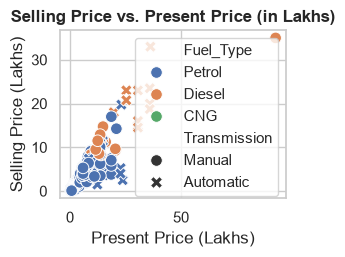

In [12]:
plt.subplot(2, 2, 1)
sns.scatterplot(
    data=df, 
    x='Present_Price', 
    y='Selling_Price', 
    hue='Fuel_Type', 
    style='Transmission', 
    s=70
)
plt.title('Selling Price vs. Present Price (in Lakhs)', fontsize=12, fontweight='bold')
plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Selling Price (Lakhs)')

Text(0, 0.5, 'Average Selling Price (Lakhs)')

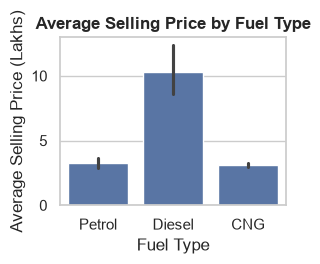

In [25]:
plt.subplot(2, 2, 2)
sns.barplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.title('Average Selling Price by Fuel Type', fontsize=12, fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price (Lakhs)')

Text(0, 0.5, 'Selling Price (Lakhs)')

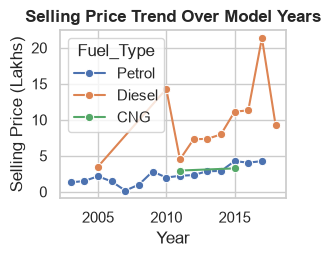

In [15]:
plt.subplot(2, 2, 4)
sns.lineplot(
    data=df, 
    x='Year', 
    y='Selling_Price', 
    hue='Fuel_Type', 
    marker='o', 
    errorbar=None
)
plt.title('Selling Price Trend Over Model Years', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Selling Price (Lakhs)')

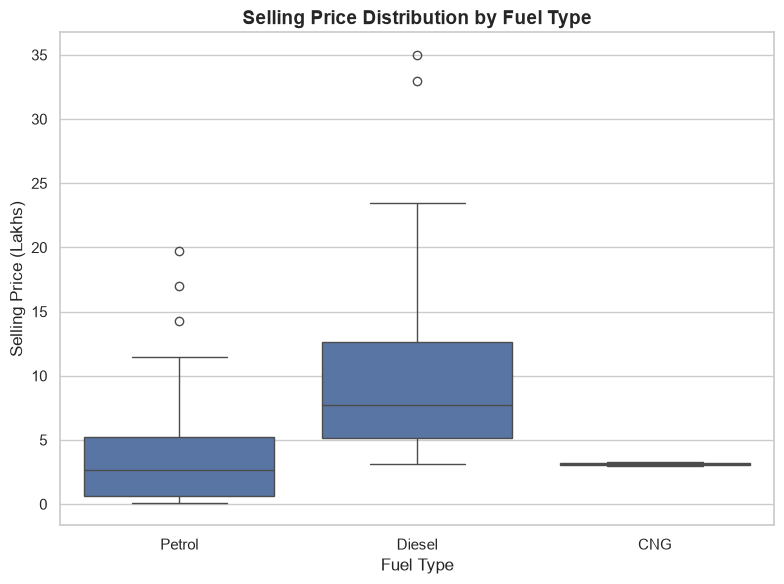

In [16]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Plot boxplot
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price')
plt.title('Selling Price Distribution by Fuel Type', fontsize=14, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Selling Price (Lakhs)', fontsize=12)

plt.tight_layout()
plt.savefig('price_by_fuel.png', dpi=300)
plt.show()

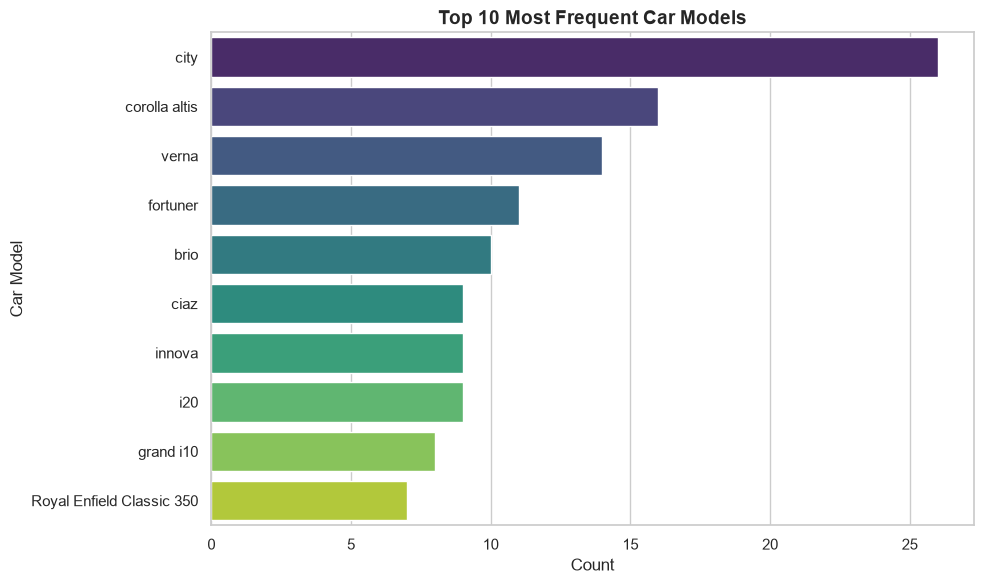

In [17]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

top_10 = df['Car_Name'].value_counts().head(10).reset_index()
top_10.columns = ['Car_Name', 'Count']

# Pass hue='Car_Name' to avoid the deprecation warning
sns.barplot(data=top_10, x='Count', y='Car_Name', hue='Car_Name', palette='viridis')

# Suppress duplicate legend
plt.legend([], frameon=False)

plt.title('Top 10 Most Frequent Car Models', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Car Model', fontsize=12)

plt.tight_layout()
plt.savefig('top_10_cars.png', dpi=300)
plt.show()

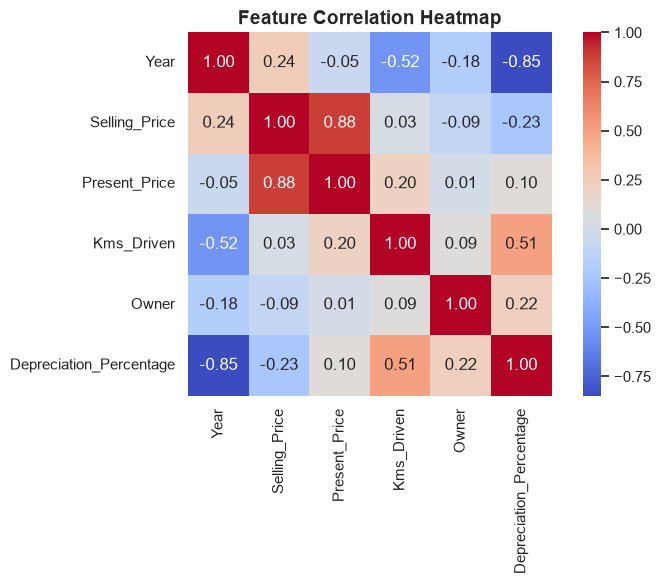

In [18]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Compute correlation matrix for numerical features
corr = df[[
    'Year', 
    'Selling_Price', 
    'Present_Price', 
    'Kms_Driven', 
    'Owner', 
    'Depreciation_Percentage'
]].corr()

# Draw heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

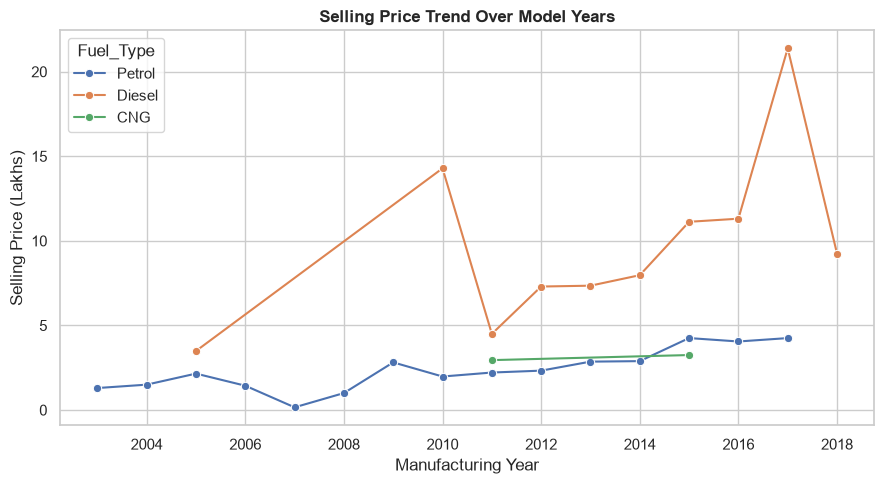

In [19]:
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df, x='Year', y='Selling_Price', hue='Fuel_Type', marker='o', errorbar=None)
plt.title('Selling Price Trend Over Model Years', fontsize=12, fontweight='bold')
plt.xlabel('Manufacturing Year')
plt.ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.savefig('graph_price_vs_year.png', dpi=300)
plt.show()

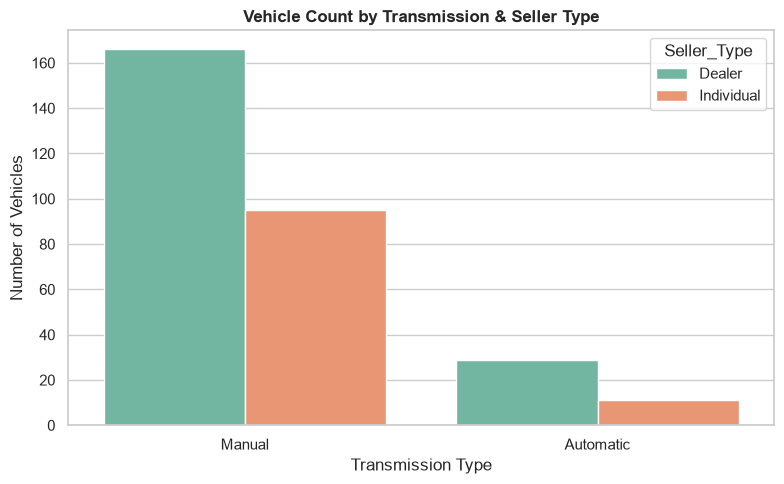

In [20]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

sns.countplot(data=df, x='Transmission', hue='Seller_Type', palette='Set2')
plt.title('Vehicle Count by Transmission & Seller Type', fontsize=12, fontweight='bold')
plt.xlabel('Transmission Type')
plt.ylabel('Number of Vehicles')

plt.tight_layout()
plt.savefig('graph_transmission_seller.png', dpi=300)
plt.show()

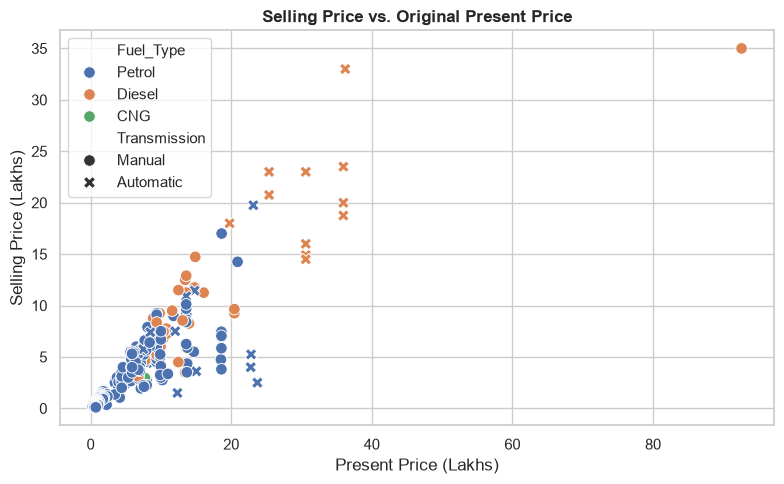

In [21]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df, 
    x='Present_Price', 
    y='Selling_Price', 
    hue='Fuel_Type', 
    style='Transmission', 
    s=70
)
plt.title('Selling Price vs. Original Present Price', fontsize=12, fontweight='bold')
plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.savefig('graph_scatter_prices.png', dpi=300)
plt.show()

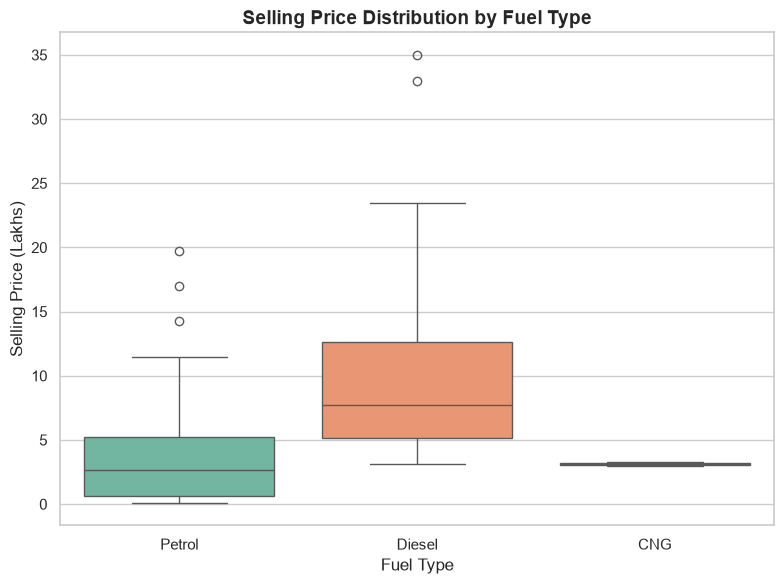

In [22]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', hue='Fuel_Type', palette='Set2')
plt.legend([], frameon=False)

plt.title('Selling Price Distribution by Fuel Type', fontsize=14, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Selling Price (Lakhs)', fontsize=12)

plt.tight_layout()
plt.savefig('price_by_fuel_fixed.png', dpi=300)
plt.show()

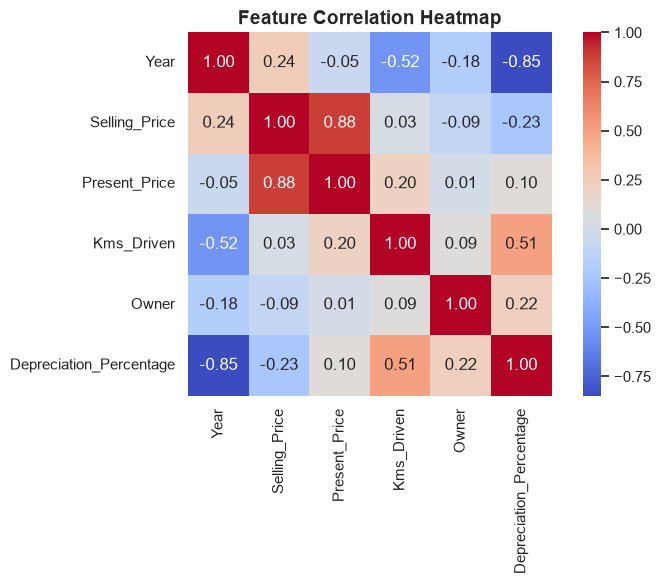

In [23]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

corr = df[['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Depreciation_Percentage']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()


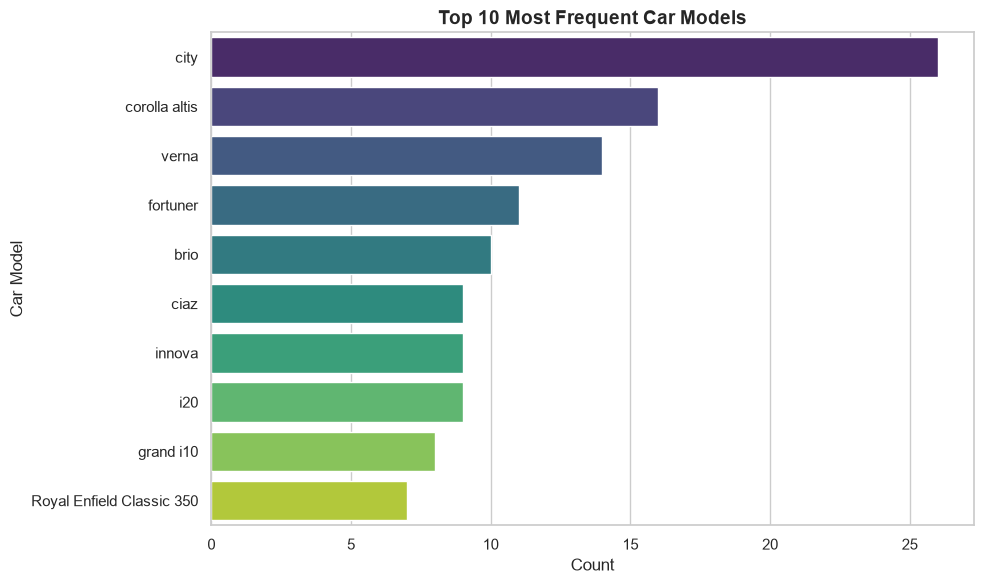

In [24]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

top_10 = df['Car_Name'].value_counts().head(10).reset_index()
top_10.columns = ['Car_Name', 'Count']

sns.barplot(data=top_10, x='Count', y='Car_Name', hue='Car_Name', palette='viridis')
plt.legend([], frameon=False)

plt.title('Top 10 Most Frequent Car Models', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Car Model', fontsize=12)

plt.tight_layout()
plt.savefig('top_10_cars.png', dpi=300)
plt.show()